<a href="https://colab.research.google.com/github/annamngz/behind-the-data/blob/main/DHDMCH_behind_the_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)

# Dietro i dati: il ruolo dei metadati nella visibilità della conoscenza scientifica

## 1. Introduzione

È facile pensare che i dati siano una **fotografia oggettiva del mondo**, ma in realtà ogni dataset è anche il risultato di un processo fatto di selezione, descrizione e organizzazione dell'informazione.

Questo progetto nasce proprio da questa domanda: **quanto la qualità dei metadati influenza ciò che possiamo osservare?**

Ho analizzato un dataset di contributi scientifici indicizzati su **Wikidata**, quindi da un ambiente particolarmente interessante perché non è una banca dati chiusa, ma un ecosistema collaborativo in continua evoluzione.

L'**obiettivo iniziale** era osservare la distribuzione della produzione scientifica. Durante l'analisi, però, è emerso un secondo livello di lettura: la presenza di un articolo nel dataset dipende anche dalla **qualità dei suoi metadati**. In un ambiente digitale, ciò che non è descritto correttamente rischia di diventare invisibile. Metadati completi e strutturati possono quindi svolgere un ruolo decisivo nel determinare la reperibilità di una pubblicazione all'interno di un sistema informativo.

Per questo motivo il progetto si è trasformato in una sorta di analisi dei dati sui dati: una meta analisi del dataset stesso, **per capire non solo cosa vediamo, ma anche perché riusciamo a vederlo**.


---


Il progetto nasce come prova d'esame del corso di Digital Humanities e Data Management per i Beni Culturali per il corso di Laurea Magistrale in Scienze del Libro e del Documento.


### 1.1. Obiettivi

* studiare la **distribuzione della produzione scientifica** attraverso alcuni strumenti della bibliometria
* indagare la **completezza dei metadati**, costruendo un indicatore in grado di valutare quanto le pubblicazioni siano adeguatamente descritte
* esplorare il **rapporto tra qualità dei metadati e visibilità della produzione scientifica**, dimostrando che una maggiore ricchezza informativa contribuisce alla visibilità nei sistemi informativi digitali

### 1.2. Dati utilizzati

I **dati in input** sono costituiti da un file CSV scaricato dal repository GitHub del corso Digital Humanities e Data Management (https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv).

I **dati in output** consistono in questo Jupyter Notebook, contenente testo e codice per l'analisi computazionale dei dati.

| Variabile | Tipo |	Definizione | Esempio |
| :----- | :--- | :--------- | :------ |
|  id     |	obj | URL Wikidata univoco | http://www.wikidata.org/entity/Q136384321	 |
|  titolo     |	obj | Titolo del contributo | Un'idea di biblioteca, un'idea di professione	 |
|  autori     |	obj | Autori del contributo e genere | Rosa Maiello (femmina), Lucia Sardo (femmina)	 |
|  data_pubblicazione     |	obj | Data di pubblicazione del contributo | 2022	 |
|  argomenti     |	obj | Tematiche principali del contributo | bibliografia; bibliotecario	 |
|  basi_dati     |	obj | Basi dati in cui è indicizzato il contributo | Scopus; DOAJ	 |
|  doi_disponibili     |	obj | DOI del contributo | 10.2426/AIBSTUDI-13398	 |
|  editori     |	obj | Editori del contributo | Giornale di Sicilia Editoriale Poligrafica		 |
|  licenze_rivista     |	obj | Licenza del contributo | Creative Commons Attribution-ShareAlike	 |
|  rivista     |	obj | Rivista nella quale è stato pubblicato il contributo | Bibliothecae.it	 |
|  edizione     |	obj | Fascicolo della rivista | 55	 |
|  volume     |	obj | Annata della rivista | 23	 |
|  pagine     |	obj | Numero o intervallo di pagine | 19	 |

### 1.3. Organizzazione

Il percorso si sviluppa attraverso **quattro fasi**:

**1**. il processamento dei dati

**2.** l'arricchimento dei record con Wikidata

**3.** l'analisi esplorativa, che consiste nell'analisi bibliometrica della produzione scientifica

**4.** l'analisi esplicativa, che si concentra sul dimostrare come una maggiore qualità dei metadati possa aumentare la visibilità delle pubblicazioni

### 1.4. Nota metodologica

Per la sezione del notebook che riguarda l'**arricchimento del dataset con Wikidata** è importante ricordare che Wikidata è una base di conoscenza dinamica e collaborativa: i dati possono essere modificati, aggiornati o arricchiti nel tempo. Per questo motivo, una stessa interrogazione effettuata in momenti diversi può produrre risultati differenti.

Durante lo sviluppo dell'analisi si è verificato concretamente questo caso: interrogazioni successive, effettuate a distanza di giorni, hanno restituito un numero diverso di risultati rispetto alla prima estrazione.

Per garantire la riproducibilità dell'analisi nonostante la natura dinamica di Wikidata, ho scelto di evitare l'inserimento di valori numerici fissi all'interno del testo.

### 1.5. Preservazione

Il dataset utilizzato in questa analisi è conservato nella repository GitHub del corso (https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv).

I dati in output verranno conservati su **GitHub** e su **Zenodo**.

### 1.6. Accesso e Utilizzo

I dati di input, il codice e l'output sono rilasciati sotto licenza **CC0 1.0 Universal**.

## 2. Caricamento e ispezione dei dati

Importiamo Pandas e creiamo il DataFrame su cui lavorare. Successivamente, ispezioniamolo.

In [182]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv")

In [183]:
df.shape

(1792, 14)

In [184]:
df.columns

Index(['id', 'titolo', 'autori', 'data_pubblicazione', 'argomenti',
       'basi_dati', 'doi_disponibili', 'editori', 'licenze_rivista', 'rivista',
       'edizione', 'volume', 'pagine', 'url_disponibili'],
      dtype='object')

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1792 entries, 0 to 1791
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1792 non-null   object
 1   titolo              1792 non-null   object
 2   autori              1376 non-null   object
 3   data_pubblicazione  1786 non-null   object
 4   argomenti           1043 non-null   object
 5   basi_dati           1248 non-null   object
 6   doi_disponibili     914 non-null    object
 7   editori             1589 non-null   object
 8   licenze_rivista     1476 non-null   object
 9   rivista             1583 non-null   object
 10  edizione            1377 non-null   object
 11  volume              1521 non-null   object
 12  pagine              1121 non-null   object
 13  url_disponibili     1344 non-null   object
dtypes: object(14)
memory usage: 196.1+ KB


In [186]:
df.head(50)

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
0,http://www.wikidata.org/entity/Q136384321,Deliberazione 21 dicembre 1993: Assegnazione a...,NaN,1994,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,55,135,NaN,NaN
1,http://www.wikidata.org/entity/Q136384538,Decreto 30 aprile 1976: Regolamento interno pe...,NaN,1976,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,126,117,NaN,NaN
2,http://www.wikidata.org/entity/Q137368051,Si tocca Corfù. Viaggi in Levante,Giacomo Caputo (maschio),1931,NaN,NaN,NaN,Giornale di Sicilia Editoriale Poligrafica,NaN,Giornale di Sicilia,NaN,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q128621600,"Meldini, fantasmi a Rimini",Giorgio Calcagno (maschio),1996,bibliografia; bibliotecario,NaN,NaN,Italiana Editrice,NaN,La Stampa,222,130,19,NaN
4,http://www.wikidata.org/entity/Q111747586,Le fonti del «Libro della natura degli animali»,Davide Checchi (maschio),2017,NaN,Scopus; Arts and Humanities Citation Index; Jo...,NaN,NaN,NaN,Studi Medievali,NaN,58,525-578,NaN
5,http://www.wikidata.org/entity/Q128694025,Bibliografia degli scritti di Gustavo Vinay (1...,Ileana Pagani (femmina),1999,bibliografia; bibliotecario,Scopus; Arts and Humanities Citation Index; Jo...,NaN,NaN,NaN,Studi Medievali,1,serie 3a 40,395; 439,NaN
6,http://www.wikidata.org/entity/Q111782067,Racconti autobiografici di vocazione della Pro...,Miriam Turrini (femmina),2020,NaN,Scopus; Journal Citation Reports; SCImago Jour...,NaN,Edizioni Scientifiche Italiane,NaN,Rivista storica italiana,NaN,132,881-903,NaN
7,http://www.wikidata.org/entity/Q128306149,Panizzi esule,Carlo Dionisotti (maschio),1980,bibliografia; Antonio Panizzi; bibliotecario,Scopus; Journal Citation Reports; SCImago Jour...,NaN,Edizioni Scientifiche Italiane,NaN,Rivista storica italiana,2,92,411; 384,NaN
8,http://www.wikidata.org/entity/Q33144512,"Cardiac myxoma: diagnostic approach, surgical ...",NaN,1996,cardiochirurgia,Scopus,NaN,NaN,NaN,NaN,6 Suppl 1,37,113-117,NaN
9,http://www.wikidata.org/entity/Q33144721,Idiopathic hypertrophic subaortic stenosis: lo...,NaN,1976,idiopatico; stenosi,Scopus,NaN,NaN,NaN,NaN,6,17,541-547,NaN


In [187]:
df.describe()

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
count,1792,1792,1376,1786,1043,1248,914,1589,1476,1583,1377,1521,1121,1344
unique,1792,1784,849,73,735,19,912,39,7,75,43,105,973,1331
top,http://www.wikidata.org/entity/Q136593329,Editoriale,Alfredo Serrai (maschio),2020,associazione; bibliotecario,Scopus; DOAJ; Emerging Sources Citation Index,10.53223/SINAPPSI_2024-01-5,Associazione Italiana Biblioteche,Creative Commons Attribution-NonCommercial-NoD...,AIB studi,1,10,1-2,http://www.ricerchedisconfine.info/index.htm
freq,1,5,61,145,30,357,2,557,540,357,543,90,18,12


Perfetto, abbiamo il nostro DataFrame e abbiamo capito un po' com'è fatto:
*   abbiamo 14 colonne e 1792 righe
*   tutte le righe sono dotate id e titolo (non c'è alcun valore nullo)
*   gli id sono univoci

Tuttavia, ci sono alcune stranezze che andrebbero indagate e corrette.

## 3. Processamento dei dati

La fase di processamento si propone di **preparare i dati per l'analisi**, andando a bonificare le situazioni problematiche. Ad esempio:

*  il datatype è sempre object, anche per la colonna `data_pubblicazione`
*  alcuni titoli si ripetono: casi di omonimia o errori?
*  abbiamo 914 DOI, ma gli univoci sono 912: indaghiamo
*  la colonna `autore` contiene due dati diversi: i nomi e il genere
*  anche gli URL non sono tutti univoci
*  le pagine sono formattate in modo fantasioso
*  la colonna `basi_dati` spesso contiene più valori nella stessa cella

Partiamo.


### 2.1 Processamento della colonna `data_pubblicazione`
Iniziamo convertendo la colonna `data_pubblicazione` da object a int. Visto che non abbiamo riferimento di mesi o giorni non serve convertirla in datetime: per semplicità trasformiamola in numeri.

Ad una prima occhiata sulla colonna vediamo che ci sono alcuni valori nulli e altri formattati in modo strano, ad esempio "1992 | 1994".

In [188]:
for value in df['data_pubblicazione']:
   if isinstance(value, str) and '|' in value:
      print(value)

1987 | 1989
1992 | 1994
1992 | 1994


Procediamo così:

*   i nulli li trasformiamo in 0 (int)
*   gli strani sono solo tre e li correggiamo manualmente


In [189]:
df["data_pubblicazione"] = df["data_pubblicazione"].replace("1987 | 1989", 1987)
df["data_pubblicazione"] = df["data_pubblicazione"].replace("1992 | 1994", 1992)

Bene, ora creiamo la funzione `converti_data` che trasformi tutto in int.

In [190]:
def converti_data(value):
    if pd.isna(value):
        return 0
    else:
        return int(value)

df['data_pubblicazione'] = df['data_pubblicazione'].apply(converti_data)

Perfetto, ora dovremmo aver ottenuto tutta la colonna `data_pubblicazione` popolata con int. Verifichiamolo.


In [191]:
df['data_pubblicazione'].dtype

dtype('int64')

Ottimo! Facciamo giusto per sicurezza un controllo statistico sui valori della colonna.

In [192]:
print('Numero di valori nulli nella colonna data_pubblicazione:', df['data_pubblicazione'].isnull().sum())
print('Numero di zeri nella colonna data_pubblicazione:', (df['data_pubblicazione'] == 0).sum())

Numero di valori nulli nella colonna data_pubblicazione: 0
Numero di zeri nella colonna data_pubblicazione: 6


Non ci sono valori nulli, ma ci sono 6 zeri. È corretto: il numero coincide con i valori nulli che presentava il dataset all'inizio e che sono stati sostituiti con 0 dalla funzione `converti_data`.
Non è un problema, ma se dovessimo aver bisogno di fare delle medie è il caso di escluderli.

### 2.2 Processamento della colonna `doi_disponibili`
Passiamo ora all'analisi dei DOI duplicati. Vediamo quali sono.

In [193]:
doi_duplicati = df[df['doi_disponibili'].notna() & df['doi_disponibili'].duplicated(keep=False)]
doi_duplicati[['id', 'titolo', 'doi_disponibili', 'url_disponibili']]

,id,titolo,doi_disponibili,url_disponibili
1579,http://www.wikidata.org/entity/Q113101630,"L'intrigo del decidere. Scienza, politica, dir...",10.53223/SINAPPSI_2022-01-6,https://oa.inapp.org/jspui/bitstream/20.500.12...
1588,http://www.wikidata.org/entity/Q113101849,I livelli essenziali alla prova dell’attuazion...,10.53223/SINAPPSI_2022-01-6,https://oa.inapp.org/jspui/bitstream/20.500.12...
1701,http://www.wikidata.org/entity/Q126372153,Professioni nella Care economy e occupazione: ...,10.53223/SINAPPSI_2024-01-5,https://oa.inapp.org/xmlui/bitstream/handle/20...
1708,http://www.wikidata.org/entity/Q130529640,Effects of employee monitoring on remote work....,10.53223/SINAPPSI_2024-01-5,https://oa.inapp.gov.it/bitstreams/3b6ee18b-73...


Ok, i DOI duplicati sono 10.53223/SINAPPSI_2022-01-6 e
10.53223/SINAPPSI_2024-01-5.
Guardando il database sembra che non si tratta di pubblicazioni identiche, ma di DOI uguali assegnati a pubblicazioni diverse.

Siccome non abbiamo modo di recuperare quello corretto, creiamo una nuova colonna, `doi_valido`. **Se il DOI è valido**, assegnamo True, **se è duplicato oppure nullo** assegnamo False.




In [194]:
doi_duplicati = ['10.53223/SINAPPSI_2022-01-6','10.53223/SINAPPSI_2024-01-5']
df['doi_valido'] = df['doi_disponibili'].notna() | df['doi_disponibili'].isin(doi_duplicati)

### 2.3 Processamento della colonna `autori`

Passiamo ora alla bonifica della colonna `autori`. L'obiettivo è separare il nome dell'autore dal suo genere e gestire i casi in cui sono presenti più autori per lo stesso record, attualmente separati da punto e virgola (`;`).

**Da notare: ci sono molti valori nulli (oltre 400!).**

Modifichiamo la colonna `autori` in modo che contenga solo i nomi, e creiamone una nuova, `generi`, con i generi corrispondenti.

Ma prima facciamoci un'idea dei casi con più autori.

In [195]:
for value in df['autori']:
    if ';' in str(value):
        print(value)

Anna Galluzzi (femmina); Chiara Faggiolani (femmina)
Angela Nuovo (femmina); Aldo Coletto (maschio)
Francesca Tomasi (femmina); Valentina Pasqual (femmina)
Giulia Crippa (femmina); Valentina Sonzini (femmina); Lucia Sardo (femmina)
Francesca Verga (femmina); Alessandra Moi (femmina); Silvana Re (femmina)
Maddalena Battaggia (femmina); Agnese Bertazzoli (femmina)
Anna Bernabè (femmina); Milena Tancredi (femmina); Serafina Spinelli (femmina)
Carlo Bianchini (maschio); Alessandra Moi (femmina); Andrea Marchitelli (maschio)
Erika Pasceri (femmina); Antonietta Folino (femmina); Claudia Lanza (femmina)
Antonietta Folino (femmina); Roberto Guarasci (maschio)
Agnese Galeffi (femmina); Paul Gabriele Weston (maschio)
Alessandra Boccone (femmina); Tania Maio (femmina)
Emiliano Diamanti (maschio); Gianni Stefanini (maschio)
Anna Galluzzi (femmina); Chiara Faggiolani (femmina)
Giulia Radin (femmina); Alessandra Basso (femmina)
Maria Cassella (femmina); Paola Gargiulo (femmina)
Anna Galluzzi (femmin

Prima di procedere con la separazione degli autori, è necessario uniformare il formato dei dati presenti nella colonna `autori`. L'obiettivo è trasformare ogni valore in una lista, così da poter gestire in modo omogeneo sia i record con un solo autore sia quelli con più autori.

Per fare questo verrà utilizzato il metodo `split()`, che suddivide una stringa utilizzando il punto e virgola (;) come separatore. Tuttavia, questa operazione può essere applicata soltanto alle stringhe: i valori nulli provocherebbero un errore. Per questo motivo, prima della trasformazione, i valori mancanti vengono sostituiti con la stringa "Non specificato". In questo modo anche i record privi di informazioni sugli autori verranno convertiti in una lista (["Non specificato"]), mantenendo un formato uniforme per l'intera colonna e semplificando tutte le elaborazioni successive.

In [196]:
df['autori'] = df['autori'].fillna('Non specificato')
df['autori']

,autori
0,Non specificato
1,Non specificato
2,Giacomo Caputo (maschio)
3,Giorgio Calcagno (maschio)
4,Davide Checchi (maschio)
...,...
1787,Dante Bandini (maschio)
1788,Patrizia Lucchini (femmina)
1789,Miranda Sacchi (femmina)
1790,Klaus-Peter Böttger (maschio)


E ora splittiamo sul punto e virgola (;).

In [197]:
df['autori'] = df['autori'].str.split('; ')
df['autori']

,autori
0,[Non specificato]
1,[Non specificato]
2,[Giacomo Caputo (maschio)]
3,[Giorgio Calcagno (maschio)]
4,[Davide Checchi (maschio)]
...,...
1787,[Dante Bandini (maschio)]
1788,[Patrizia Lucchini (femmina)]
1789,[Miranda Sacchi (femmina)]
1790,[Klaus-Peter Böttger (maschio)]


Assicuriamoci che non esistano autori senza l'indicazione del genere tra parentesi.

In [198]:
for autori in df['autori']:
  if autori != ['Non specificato']:
        for autore in autori:
            if '(' not in autore:
                print(autore)

Ok, ora l'ultimo passaggio: separiamo i generi dai nomi inserendoli nella colonna `generi`.

In [199]:
def estrai_generi(autori):
    if autori == ['Non specificato']:
        return ['Non specificato']

    generi = []

    for autore in autori:
        genere = autore.split('(')[1].replace(')', '')
        generi.append(genere)

    return generi

df['generi'] = df['autori'].apply(estrai_generi)
df[['autori', 'generi']]

,autori,generi
0,[Non specificato],[Non specificato]
1,[Non specificato],[Non specificato]
2,[Giacomo Caputo (maschio)],[maschio]
3,[Giorgio Calcagno (maschio)],[maschio]
4,[Davide Checchi (maschio)],[maschio]
...,...,...
1787,[Dante Bandini (maschio)],[maschio]
1788,[Patrizia Lucchini (femmina)],[femmina]
1789,[Miranda Sacchi (femmina)],[femmina]
1790,[Klaus-Peter Böttger (maschio)],[maschio]


Ora ricordiamoci di eliminare il dato del genere dalla colonna `autori`.

In [200]:
def estrai_nomi(autori):
    if autori == ['Non specificato']:
        return ['Non specificato']

    nomi = []

    for autore in autori:
        nome = autore.split('(')[0].strip()
        nomi.append(nome)

    return nomi

df['autori'] = df['autori'].apply(estrai_nomi)

Abbiamo sostituito i valori nulli con [Non specificato], separato i nomi dai generi e creato la nuova colonna `generi`. A questo punto verifichiamo che sia andato tutto a posto.




In [201]:
df[['autori', 'generi']]

,autori,generi
0,[Non specificato],[Non specificato]
1,[Non specificato],[Non specificato]
2,[Giacomo Caputo],[maschio]
3,[Giorgio Calcagno],[maschio]
4,[Davide Checchi],[maschio]
...,...,...
1787,[Dante Bandini],[maschio]
1788,[Patrizia Lucchini],[femmina]
1789,[Miranda Sacchi],[femmina]
1790,[Klaus-Peter Böttger],[maschio]


Benissimo!

## 4. Arricchimento del dataset con Wikidata

Rimane però il fatto che abbiamo parecchi record senza autore (quelli che erano nulli che abbiamo sostituito con [Non specificato]).
Considerato che si tratta di articoli scientifici, è molto strano.

Scopriamo cos'è successo.

In [202]:
autori_non_specificati = df[df['autori'].apply(lambda x: x == ['Non specificato'])].copy()
autori_non_specificati

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili,doi_valido,generi
0,http://www.wikidata.org/entity/Q136384321,Deliberazione 21 dicembre 1993: Assegnazione a...,[Non specificato],1994,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,55,135,NaN,NaN,False,[Non specificato]
1,http://www.wikidata.org/entity/Q136384538,Decreto 30 aprile 1976: Regolamento interno pe...,[Non specificato],1976,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,126,117,NaN,NaN,False,[Non specificato]
8,http://www.wikidata.org/entity/Q33144512,"Cardiac myxoma: diagnostic approach, surgical ...",[Non specificato],1996,cardiochirurgia,Scopus,NaN,NaN,NaN,NaN,6 Suppl 1,37,113-117,NaN,False,[Non specificato]
9,http://www.wikidata.org/entity/Q33144721,Idiopathic hypertrophic subaortic stenosis: lo...,[Non specificato],1976,idiopatico; stenosi,Scopus,NaN,NaN,NaN,NaN,6,17,541-547,NaN,False,[Non specificato]
19,http://www.wikidata.org/entity/Q117428678,Per una visione sistemica del prestito digital...,[Non specificato],2022,e-book,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13374,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,1,62,57-72,https://aibstudi.aib.it/article/view/13374,True,[Non specificato]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1738,http://www.wikidata.org/entity/Q131869976,... Dalla Laguna,[Non specificato],1991,bibliotecario; associazione,NaN,NaN,NaN,NaN,Bibliotime (Print),1,2,1-6,NaN,False,[Non specificato]
1752,http://www.wikidata.org/entity/Q135391256,Archivio Gentile,[Non specificato],2003,archivistica,NaN,NaN,Società savonese di storia patria,NaN,Atti e memorie. Società Savonese di Storia Patria,NaN,39,331-334,NaN,False,[Non specificato]
1755,http://www.wikidata.org/entity/Q127043422,Operatore dei beni culturali: una nuova figura...,[Non specificato],1994,bibliotecario; insegnamento; formazione profes...,NaN,NaN,NaN,NaN,Notiziario dell'Università degli studi di Udine,1,10,17,NaN,False,[Non specificato]
1781,http://www.wikidata.org/entity/Q135011215,C'era una volta LiBeR: frammenti di storia per...,[Non specificato],2001,libro; periodico; adolescente,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,NaN,50,17-21,NaN,False,[Non specificato]


Facendo dei controlli a campione su Wikidata, per questi record si presentano diverse situazioni:


*   manca effettivamente la proprietà `author` (P50)
*   la proprietà c'è, ma non è valorizzata
*   l'autore è inserito con la proprietà `author name string` (P2093) al posto di `author` (P50)

Nei primi due casi, non possiamo fare nulla, ma possiamo **provare a recuperare le stringhe inserite con la proprietà P2093** interrogando l'API di Wikidata.

Come prima cosa, ricaviamoci l'id di Wikidata.




In [203]:
autori_non_specificati["qid"] = autori_non_specificati["id"].str.split("/").str[-1]
autori_non_specificati["qid"]

,qid
0,Q136384321
1,Q136384538
8,Q33144512
9,Q33144721
19,Q117428678
...,...
1738,Q131869976
1752,Q135391256
1755,Q127043422
1781,Q135011215


Per ogni QID interroghiamo l'API di Wikidata in modo che ci restituisca un file JSON contenente tutte le informazioni disponibili per quell'entità. Lo script analizza la risposta e cerca la proprietà P2093. Quando presente, salviamo il risultato in una nuova colonna `autore_p2093`. In questo modo conserviamo sia il dato originale sia l'informazione eventualmente recuperata da Wikidata, permettendoci poi di decidere come integrare i due livelli.

In [204]:
import requests

def recupera_autore_p2093(qid):
    url = f"https://www.wikidata.org/wiki/Special:EntityData/{qid}.json"

    headers = {"User-Agent": "AnalisiDatasetBibliografico/1.0"}

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        return None

    data = response.json()

    try:
        claims = data["entities"][qid]["claims"]["P2093"]
    except KeyError:
        return None

    autori = []

    for claim in claims:
        try:
            valore = claim["mainsnak"]["datavalue"]["value"]
            autori.append(valore)
        except KeyError:
            continue


    if autori:
        return autori
    else:
        return None

autori_non_specificati["autore_p2093"] = autori_non_specificati["qid"].apply(recupera_autore_p2093)

In [205]:
autori_non_specificati["autore_p2093"]

,autore_p2093
0,None
1,None
8,"[J Jelic, D Milicić, I Alfirević, D Anić, Z Ba..."
9,"[P. Jaumin, J. Cosyns, Y. Kestens-Servaye, R. ..."
19,[Fabio Mercanti]
...,...
1738,None
1752,None
1755,None
1781,None


Il momento della verità: verifichiamo cosa ci ha restituito Wikidata.

In [206]:
autori_non_specificati[autori_non_specificati["autore_p2093"].notna()][["qid", "autore_p2093"]]

,qid,autore_p2093
8,Q33144512,"[J Jelic, D Milicić, I Alfirević, D Anić, Z Ba..."
9,Q33144721,"[P. Jaumin, J. Cosyns, Y. Kestens-Servaye, R. ..."
19,Q117428678,[Fabio Mercanti]
24,Q117447504,[Anna Gruzova]
27,Q117447505,[Federica Olivotto]
...,...,...
1369,Q104250761,[Franca Trincia]
1382,Q104382473,"[Caterina Guiducci, Giovanna Lambroni, Chiara ..."
1431,Q104382472,[Lucilla Conigliello]
1444,Q126348563,[Giulia Tozzi]


Interrogare la proprietà P2093 ci ha consentito un notevole arricchimento della colonna `autore`, ma in molti casi abbiamo delle forme non normalizzate. Chiaramente non è la situazione ottimale, ma sempre meglio di NaN.

In [207]:
autori_non_specificati

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili,doi_valido,generi,qid,autore_p2093
0,http://www.wikidata.org/entity/Q136384321,Deliberazione 21 dicembre 1993: Assegnazione a...,[Non specificato],1994,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,55,135,NaN,NaN,False,[Non specificato],Q136384321,None
1,http://www.wikidata.org/entity/Q136384538,Decreto 30 aprile 1976: Regolamento interno pe...,[Non specificato],1976,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,126,117,NaN,NaN,False,[Non specificato],Q136384538,None
8,http://www.wikidata.org/entity/Q33144512,"Cardiac myxoma: diagnostic approach, surgical ...",[Non specificato],1996,cardiochirurgia,Scopus,NaN,NaN,NaN,NaN,6 Suppl 1,37,113-117,NaN,False,[Non specificato],Q33144512,"[J Jelic, D Milicić, I Alfirević, D Anić, Z Ba..."
9,http://www.wikidata.org/entity/Q33144721,Idiopathic hypertrophic subaortic stenosis: lo...,[Non specificato],1976,idiopatico; stenosi,Scopus,NaN,NaN,NaN,NaN,6,17,541-547,NaN,False,[Non specificato],Q33144721,"[P. Jaumin, J. Cosyns, Y. Kestens-Servaye, R. ..."
19,http://www.wikidata.org/entity/Q117428678,Per una visione sistemica del prestito digital...,[Non specificato],2022,e-book,Scopus; DOAJ; Emerging Sources Citation Index,10.2426/AIBSTUDI-13374,Associazione Italiana Biblioteche,Creative Commons Attribution-ShareAlike; Creat...,AIB studi,1,62,57-72,https://aibstudi.aib.it/article/view/13374,True,[Non specificato],Q117428678,[Fabio Mercanti]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1738,http://www.wikidata.org/entity/Q131869976,... Dalla Laguna,[Non specificato],1991,bibliotecario; associazione,NaN,NaN,NaN,NaN,Bibliotime (Print),1,2,1-6,NaN,False,[Non specificato],Q131869976,None
1752,http://www.wikidata.org/entity/Q135391256,Archivio Gentile,[Non specificato],2003,archivistica,NaN,NaN,Società savonese di storia patria,NaN,Atti e memorie. Società Savonese di Storia Patria,NaN,39,331-334,NaN,False,[Non specificato],Q135391256,None
1755,http://www.wikidata.org/entity/Q127043422,Operatore dei beni culturali: una nuova figura...,[Non specificato],1994,bibliotecario; insegnamento; formazione profes...,NaN,NaN,NaN,NaN,Notiziario dell'Università degli studi di Udine,1,10,17,NaN,False,[Non specificato],Q127043422,None
1781,http://www.wikidata.org/entity/Q135011215,C'era una volta LiBeR: frammenti di storia per...,[Non specificato],2001,libro; periodico; adolescente,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,NaN,50,17-21,NaN,False,[Non specificato],Q135011215,None


Arrivati a questo punto, sostituiamo i valori nulli (cioè quelli per cui Wikidata non ha restituito niente) con una lista di un solo elemento ([Non specificato]), come abbiamo fatto nella colonna autori. Ci permetterà di fare dei confronti più efficienti tra le due colonne.

In [208]:
autori_non_specificati["autore_p2093"] = (autori_non_specificati["autore_p2093"].apply(lambda x: ["Non specificato"] if x is None else x))

In [209]:
autori_non_specificati[["qid", "autore_p2093"]].head(20)

,qid,autore_p2093
0,Q136384321,[Non specificato]
1,Q136384538,[Non specificato]
8,Q33144512,"[J Jelic, D Milicić, I Alfirević, D Anić, Z Ba..."
9,Q33144721,"[P. Jaumin, J. Cosyns, Y. Kestens-Servaye, R. ..."
19,Q117428678,[Fabio Mercanti]
24,Q117447504,[Anna Gruzova]
27,Q117447505,[Federica Olivotto]
28,Q117447582,"[Marta Magadán-Díaz, Jesús I. Rivas-García]"
37,Q117448475,[Scientific and Cultural Organization UNESCO U...
38,Q117448473,[Andrea Nardi]


Momento catartico: facciamo il merge tra gli autori recuperati da Wikidata e la colonna `autori`. Ma prima facciamone una copia che non si sa mai! Successivamente, aggiungiamo la colonna autore_p2093 al DataFrame principale.

In [210]:
df["autori_originali"] = df["autori"]

In [211]:
df = df.merge(autori_non_specificati[["id", "autore_p2093"]],on="id",how="left")

In [212]:
display(df)

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili,doi_valido,generi,autori_originali,autore_p2093
0,http://www.wikidata.org/entity/Q136384321,Deliberazione 21 dicembre 1993: Assegnazione a...,[Non specificato],1994,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,55,135,NaN,NaN,False,[Non specificato],[Non specificato],[Non specificato]
1,http://www.wikidata.org/entity/Q136384538,Decreto 30 aprile 1976: Regolamento interno pe...,[Non specificato],1976,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,126,117,NaN,NaN,False,[Non specificato],[Non specificato],[Non specificato]
2,http://www.wikidata.org/entity/Q137368051,Si tocca Corfù. Viaggi in Levante,[Giacomo Caputo],1931,NaN,NaN,NaN,Giornale di Sicilia Editoriale Poligrafica,NaN,Giornale di Sicilia,NaN,NaN,NaN,NaN,False,[maschio],[Giacomo Caputo],NaN
3,http://www.wikidata.org/entity/Q128621600,"Meldini, fantasmi a Rimini",[Giorgio Calcagno],1996,bibliografia; bibliotecario,NaN,NaN,Italiana Editrice,NaN,La Stampa,222,130,19,NaN,False,[maschio],[Giorgio Calcagno],NaN
4,http://www.wikidata.org/entity/Q111747586,Le fonti del «Libro della natura degli animali»,[Davide Checchi],2017,NaN,Scopus; Arts and Humanities Citation Index; Jo...,NaN,NaN,NaN,Studi Medievali,NaN,58,525-578,NaN,False,[maschio],[Davide Checchi],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,http://www.wikidata.org/entity/Q136760137,Ragazzi in soffitta,[Dante Bandini],1990,arredamento; edilizia,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,9,ott-dic 1990,32-37,NaN,False,[maschio],[Dante Bandini],NaN
1788,http://www.wikidata.org/entity/Q137392384,"Libri alla griglia: nascita, diffusione, fortu...",[Patrizia Lucchini],0,antologia; insegnamento; gestione,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,NaN,NaN,NaN,NaN,False,[femmina],[Patrizia Lucchini],NaN
1789,http://www.wikidata.org/entity/Q137393272,Chi deve scegliere i libri in biblioteca?,[Miranda Sacchi],2000,antologia; insegnamento; gestione,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,47,NaN,31,NaN,False,[femmina],[Miranda Sacchi],NaN
1790,http://www.wikidata.org/entity/Q135435931,Biblioteca 2007: un appello per la riforma del...,[Klaus-Peter Böttger],2004,biblioteconomia; paese straniero; politica cul...,NaN,NaN,NaN,NaN,"51. Congresso nazionale AIB, AIB2004, Roma",NaN,NaN,NaN,NaN,False,[maschio],[Klaus-Peter Böttger],NaN


La colonna che abbiamo appena aggiunto al DataFrame `autore_p2093` contiene tre tipi di dato:
* nullo, se l'id non era compreso nei 416 che abbiamo chiesto a Wikidata (l'autore era già presente nel dataset originale)
* [Non specificato], se la chiamata a Wikidata non ha restituito nulla
* ['Nome autore', ...], se la chiamata ha ritornato qualcosa

A questo punto vogliamo prendere tutti quelli che si trovano nell'ultimo caso e schiacciarli nella colonna `autori`. Per farlo dobbiamo escludere i NaN della colonna `autore_p2093` e schiacciare il resto nella colonna `autori`. Che succede con i [Non specificato] della colonna `autore_p2093`? Nulla, perché il valore sarà identico anche nella colonna `autori`.

Verifichiamo che ci sia l'esatta corrispondenza:

In [213]:
conteggio_autori_validi = (df["autori"].apply(lambda x: x != ["Non specificato"]).sum())

print("Autori validi in autori:", conteggio_autori_validi)
print("Autori nulli in autore_p2093:", df["autore_p2093"].isna().sum())

Autori validi in autori: 1376
Autori nulli in autore_p2093: 1376


Bene. Procediamo!

In [214]:
mask = df["autore_p2093"].notna()
df.loc[mask, "autori"] = df.loc[mask, "autore_p2093"]

Ci rimane solo da eliminare la colonna autori_originali (la copia di sicurezza che ora non ci serve più).

In [215]:
df = df.drop(columns=["autori_originali"])

### Richiamo alla nota metodologica

Durante lo sviluppo dell'analisi, le estrazioni effettuate a distanza di giorni **hanno restituito un numero ridotto di risultati rispetto alla prima estrazione**.

Una riduzione nel numero di risultati non indica necessariamente una perdita di informazioni. Un autore precedentemente registrato come stringa testuale potrebbe essere stato successivamente collegato a una specifica entità Wikidata attraverso la proprietà P50, migliorando la qualità del dato ma rendendolo non più intercettabile dalla sola ricerca su P2093.

### 2.5 Processamento della colonna `rivista`

Controlliamo anche la colonna rivista togliendo i valori nulli e verificando che non ci siano doppioni o nomi mal formattati.

In [216]:
df['rivista'] = df['rivista'].fillna('Non specificato')

In [217]:
riviste = sorted(df["rivista"].unique())

for rivista in riviste:
    print(rivista)

51. Congresso nazionale AIB, AIB2004, Roma
AIB studi
Aevum
Africa
Annali dell'Istituto Superiore di Sanità
Annali dell'Istituto storico italo-germanico in Trento
Annali della Scuola Normale Superiore di Pisa. Classe di Lettere e Filosofia
Annali di Storia delle Universita Italiane
Associazione Italiana Biblioteche
Athenaeum
Atti della Accademia ligure di scienze e lettere
Atti della Società Italiana di Scienze Naturali
Atti e memorie. Società Savonese di Storia Patria
Bibelot
Biblioteche Oggi Trends
Bibliothecae.it
Bibliotime (Print)
Bollettino d'Arte
Bollettino della Societa italiana di biologia sperimentale
Bollettino storico-bibliografico subalpino
Contemporanea
Diacronie. Studi di Storia Contemporanea
ESB forum
Figure
Fondazione Bruno Kessler
Fragmenta Entomologica
Gazzetta Ufficiale della Repubblica Italiana
Giornale di Sicilia
Giornale storico della letteratura italiana
Il segno della Diocesi di Milano
International Journal of Speleology
Italia contemporanea
La Cultura
La Rivista

Perfetto. Direi che ci siamo! Abbiamo un nuovo DataFrame bello pulito:

* `data_pubblicazione` è un numero e non ha valori nulli
* abbiamo gestito i DOI duplicati con una nuova colonna `doi_valido`
* `autori` contiene solo i nomi degli autori e abbiamo ridotto il numero di record con valori nulli grazie a Wikidata
* abbiamo una nuova colonna `generi`
* la colonna `rivista` è normalizzata

È l'ora della Exporatory Data Analysis.

## 5. Exploratory Data Analysis
### Chi produce e dove circola la conoscenza scientifica

Stiamo trattando un dataset di contributi scientifici: chiamiamo dunque in causa le leggi bibliometriche!

La **bibliometria** è la disciplina che studia la produzione scientifica attraverso metodi quantitativi. Andremo ad indagare la legge di Lotka, che descrive la distribuzione della produttività degli autori, e la legge di Bradford, che analizza la concentrazione degli articoli nelle riviste scientifiche.

L'obiettivo di questa fase non è tanto confermare delle teorie, quanto lasciarsi guidare dai dati. L'analisi esplorativa, infatti, serve soprattutto a osservare e porsi nuove domande. Chi lo sa, magari proprio da un risultato che emergerà in questa fase prenderà forma la Explanatory Data Analysis.

Proviamo intanto a capire com'è la distribuzione degli articoli per autore.

In [218]:
autori_esplosi = df['autori'].explode()
autori_esplosi = autori_esplosi[autori_esplosi != 'Non specificato']
autori_unici = autori_esplosi.value_counts()

display(autori_unici.head(100))

,count
autori,
Alfredo Serrai,61
Fiammetta Sabba,25
Giovanni Solimine,22
Fabio Terzani,17
Anna Galluzzi,17
...,...
Laura Manzoni,3
Giovanna Di Castro,3
Luca Ferrieri,3


Già che ci siamo vediamo anche com'è la distribuzione per rivista.

In [219]:
distribuzione_riviste = df['rivista'].value_counts()
print(distribuzione_riviste)

rivista
AIB studi                                                         357
Bibliothecae.it                                                   337
Non specificato                                                   209
SINAPPSI. Connessioni tra ricerca e politiche pubbliche           175
Bibelot                                                           136
                                                                 ... 
RiMe. Rivista dell'Istituto di Storia dell'Europa Mediterranea      1
Rivista elettronica di neuroscienze                                 1
Trend                                                               1
Studi trentini di scienze storiche                                  1
Rezzara notizie                                                     1
Name: count, Length: 76, dtype: int64


Interessante: Bibliothecae.it, la rivista del Dipartimento di Beni Culturali dell'Università di Bologna è in seconda posizione per numero di articoli. Ci torneremo.

### 3.1 La produttività degli autori: la legge di Lotka

Una delle principali leggi bibliometriche è la legge di Lotka, formulata dal matematico e statistico Alfred J. Lotka nel 1926. Essa descrive la **distribuzione della produttività scientifica degli autori**, osservando che la maggior parte degli studiosi pubblica un solo lavoro, mentre un numero progressivamente minore di autori produce due, tre o più pubblicazioni. La distribuzione assume quindi una forma fortemente sbilanciata, con pochi autori molto prolifici e molti autori occasionali.

Il nostro dataset presenta un andamento compatibile con la legge di Lotka?

In [220]:
produttivita_autori = autori_esplosi.value_counts()
lotka = produttivita_autori.value_counts().sort_index()
lotka

,count
count,
1,831
2,132
3,43
4,22
5,19
6,13
7,2
8,8
9,3


Come previsto, la maggioranza degli autori contribuisce con una sola pubblicazione, mentre un numero molto più ristretto presenta una produttività superiore. Questo andamento è coerente con il principio descritto dalla legge di Lotka, secondo cui la produzione scientifica tende a concentrarsi in un piccolo gruppo di autori altamente produttivi.

Vediamolo meglio in un grafico.

<Axes: title={'center': 'Il dataset segue la Legge di Lotka'}, xlabel='Numero di articoli per autore', ylabel='Numero di autori'>

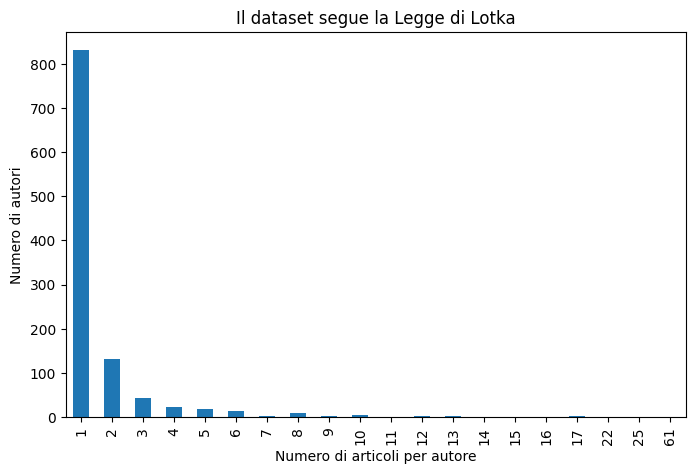

In [221]:
lotka.plot.bar(
    figsize=(8, 5),
    title="Il dataset segue la Legge di Lotka",
    xlabel="Numero di articoli per autore",
    ylabel="Numero di autori",
    legend=False
)

### 3.2 La distribuzione per rivista: la legge di Bradford

La legge di Bradford, formulata dal bibliotecario Samuel C. Bradford nel 1934, descrive il modo in cui gli articoli scientifici si distribuiscono tra le riviste. Secondo questa legge, la produzione scientifica non è distribuita uniformemente: **un numero ristretto di riviste concentra una quota significativa degli articoli, mentre un numero crescente di riviste contribuisce con un numero sempre minore di pubblicazioni**.

L'obiettivo di questa analisi è verificare se il dataset presenta una distribuzione compatibile con la legge di Bradford.
Ricordiamoci di togliere dal conteggio le righe in cui la rivista non è specificata.

In [222]:
riviste_valide = df[df['rivista'] != 'Non specificato']

In [223]:
produttivita_riviste = riviste_valide["rivista"].value_counts()
bradford = produttivita_riviste.value_counts().sort_index()
bradford

,count
count,
1,28
2,14
3,8
4,1
5,1
6,4
7,2
9,3
10,1


Visualizziamolo in un grafico.

<Axes: title={'center': 'Il dataset segue la Legge di Bradford'}, xlabel='Rivista', ylabel='Numero di articoli per rivista'>

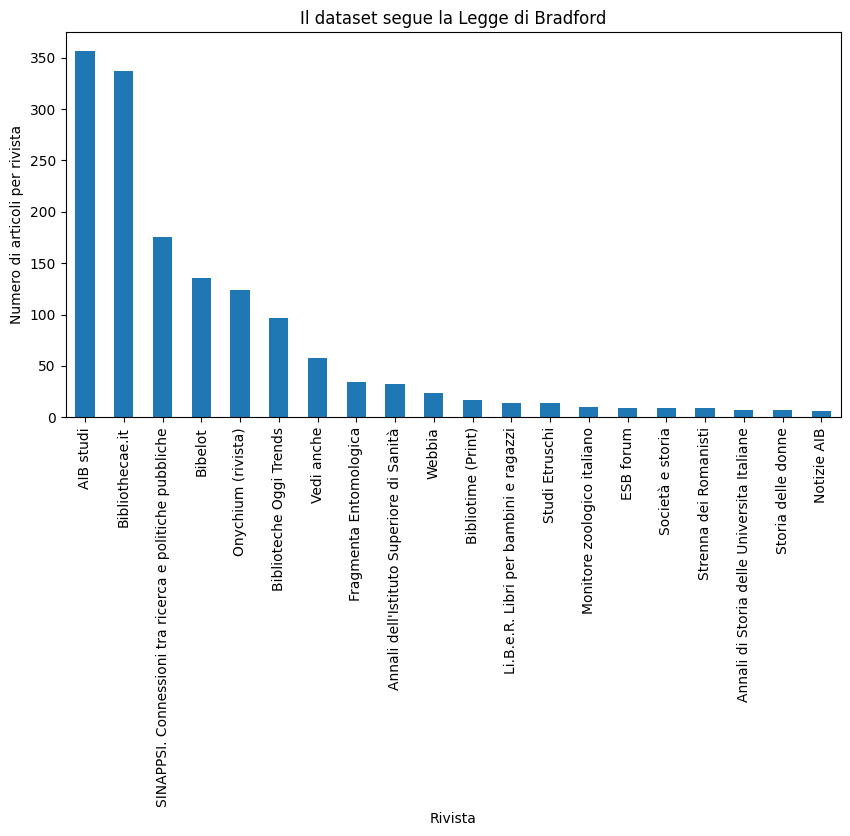

In [224]:
produttivita_riviste.head(20).plot.bar(
    figsize=(10, 5),
    title="Il dataset segue la Legge di Bradford",
    xlabel="Rivista",
    ylabel="Numero di articoli per rivista",
    legend=False
)

Questo andamento è coerente con la Legge di Bradford, confermando che il nostro dataset segue questo modello di concentrazione bibliometrica.

La maggior parte degli articoli è pubblicata da un numero molto piccolo di riviste. Vediamo quanti articoli sono coperti dalle prime tre riviste più produttive.

In [225]:
top_riviste = produttivita_riviste.head(3)
print('Percentuale articoli coperti dalle prime 3 riviste:',(top_riviste.sum() / len(riviste_valide) * 100),"%")

Percentuale articoli coperti dalle prime 3 riviste: 54.89576753000631 %


Come volevasi dimostrare, **le prime tre riviste più produttive coprono da sole più della metà degli articoli del dataset**.

Come avevamo notato anche prima, tra le riviste più produttive nel nostro dataset c'è anche **Bibliothecae.it**, la rivista del Dipartimento di Beni Culturali dell'Università di Bologna.

È un fatto curioso: una rivista semestrale e di recente fondazione che raggiunge una posizione così elevata nella classifica, con pochissimo scarto dalla prima, AIB Studi, una rivista più nota (probabilmente la più famosa nel settore biblioteconomico) e con una periodicità di pubblicazione più frequente.

Questo sarà il nostro tema per l'Explanatory Data Analysis.

## 6. Explanatory Data Analysis
###  Bibliothecae.it come caso di studio di qualità editoriale e completezza dei metadati bibliografici

L’analisi della distribuzione degli articoli per rivista evidenzia una concentrazione significativa della produzione scientifica in alcune testate. Tra queste, emerge il caso di **Bibliothecae.it**, che **si colloca al secondo posto per numero di articoli presenti nel dataset**, con 337 contributi, a breve distanza da AIB studi, che ne registra 357.

Il dato risulta interessante se interpretato alla luce delle caratteristiche editoriali delle due riviste. AIB studi, oltre ad avere una maggiore frequenza di pubblicazione, vanta una lunga tradizione editoriale nell’ambito della biblioteconomia (la rivista nasce nel 1955 con il nome "Notizie AIB. Bollettino dell'Associazione italiana biblioteche"). Sulla pagina About del suo sito https://aibstudi.aib.it/about si definisce "la rivista italiana di biblioteconomia più diffusa".

Bibliothecae.it è nata solo nel 2012 e ha una periodicità semestrale, ma raggiunge una presenza quasi equivalente nel dataset.

In [226]:
df[df['rivista'] == 'Bibliothecae.it']

,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili,doi_valido,generi,autore_p2093
663,http://www.wikidata.org/entity/Q107395001,Una Giornata per la scienza aperta: ‘Viaggiato...,"[Fiammetta Sabba, Annantonia Martorano, Elisab...",2021,Grand Tour,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/13078,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,10,488-509,https://bibliothecae.unibo.it/article/view/13078,True,"[femmina, femmina, femmina, femmina, femmina, ...",NaN
664,http://www.wikidata.org/entity/Q96623091,La Biblioteca della Camera dei deputati tra st...,"[Mauro Guerrini, Rossano De Laurentiis]",2020,Palazzo Montecitorio; storia della biblioteca;...,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/11160,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,9,469-491,https://bibliothecae.unibo.it/article/view/11160,True,"[maschio, maschio]",NaN
665,http://www.wikidata.org/entity/Q104786698,La nuova rubrica Voci di biblioteche viventi,[Fiammetta Sabba],2020,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/11817,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,9,1-3,https://bibliothecae.unibo.it/article/view/11817,True,[femmina],NaN
666,http://www.wikidata.org/entity/Q104786702,Iside a Bologna: Hieroglyphica e Aegyptiaca ne...,[Antonella Brunelli],2020,storia del libro; storia dell'editoria; Iside;...,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/11991,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,9,203-277,https://bibliothecae.unibo.it/article/view/11991,True,[femmina],NaN
667,http://www.wikidata.org/entity/Q104786701,Patrimonio librario antico e biblioteche relig...,[Giovanna Granata],2020,Ordine dei frati minori cappuccini; storia del...,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/11990,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,2,9,167-202,https://bibliothecae.unibo.it/article/view/11990,True,[femmina],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1187,http://www.wikidata.org/entity/Q135102883,«Trusted stewards of cultural heritage materia...,[Tania Maio],2025,addestramento; International Federation of Lib...,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/22268,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,14,208-223,https://bibliothecae.unibo.it/article/view/22268,True,[femmina],NaN
1188,http://www.wikidata.org/entity/Q135102881,Il De Bibliotheca Augusta di Johann Schwarzkop...,[Diego Baldi],2025,Hermann Conring; Giusto Lipsio; Herzog August ...,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/22278,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,14,104-183,https://bibliothecae.unibo.it/article/view/22278,True,[maschio],NaN
1189,http://www.wikidata.org/entity/Q135102886,"Nascita, vita e miracoli della mia biblioteca",[Ambrogio Borsani],2025,NaN,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/22267,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,14,232-240,https://bibliothecae.unibo.it/article/view/22267,True,[maschio],NaN
1190,http://www.wikidata.org/entity/Q135102884,Il progetto PNRR ‘DigiLetClass - Digitizing le...,[Fiammetta Sabba],2025,digitalizzazione; storia della biblioteca; cor...,Scopus; Google Scholar; DOAJ; SCImago Journal ...,10.6092/ISSN.2283-9364/22273,Università di Bologna,Creative Commons Attribution-NonCommercial-NoD...,Bibliothecae.it,1,14,224-231,https://bibliothecae.unibo.it/article/view/22273,True,[femmina],NaN


Osservando il dataset ci pare di notare che i record di Bibliothecae.it siano quasi sempre completi e ben formattati. Questo porta a formulare un'ipotesi: la sua elevata presenza potrebbe non dipendere soltanto dalla produzione scientifica effettiva, ma anche dalla **qualità dei metadati con cui i suoi articoli sono descritti in Wikidata**. Metadati più completi rendono infatti le pubblicazioni più facili da identificare e recuperare.

Scopriamolo creando un parametro che chiameremo `completezza_metadati` e calcoliamolo prendendo in considerazione le colonne titolo, autori, data, argomenti, basi dati, doi_valido, editori, licenze, pagine, url_disponibili.

Attribuiamo un malus se troviamo l'autore nella colonna `autori_p2093`, perché significa che il dato c'era (quindi un mezzo punto se lo merita) ma non era strutturato bene.

In [227]:
def calcola_completezza(row):
    punteggio = 0

    if pd.notna(row["titolo"]):
        punteggio += 1

    if row["autori"] != ["Non specificato"]:
        punteggio += 1

    if row["data_pubblicazione"] != 0:
        punteggio += 1

    if pd.notna(row["argomenti"]):
        punteggio += 1

    if pd.notna(row["basi_dati"]):
        punteggio += 1

    if pd.notna(row["editori"]):
        punteggio += 1

    if pd.notna(row["licenze_rivista"]):
        punteggio += 1

    if pd.notna(row["pagine"]):
        punteggio += 1

    if pd.notna(row["url_disponibili"]):
        punteggio += 1

    if row["doi_valido"] == True:
        punteggio += 1

    if (isinstance(row["autore_p2093"], list) and row["autore_p2093"] != ["Non specificato"]):
        punteggio -= 0.5

    return punteggio


In [228]:
df["completezza_metadati"] = df.apply(calcola_completezza, axis=1)

Teoricamente il punteggio minimo è -0.5 e il massimo è 10. Verifichiamo che la funzione abbia prodotto dei valori sensati.

In [229]:
df["completezza_metadati"].describe()

,completezza_metadati
count,1792.000000
mean,7.669922
std,1.738568
min,3.000000
25%,6.000000
50%,8.000000
75%,9.000000
max,10.000000


E ora stiampiamo le riviste per ordine di punteggio di `completezza_metadati`.

**Se la nostra ipotesi è corretta, Bibliothecae.it dovrebbe essere abbastanza in alto nella classifica.**

In [230]:
df.groupby("rivista")["completezza_metadati"].mean().sort_values(ascending=False)

,completezza_metadati
rivista,
Ricerche di Pedagogia e Didattica,10.000000
Bibliothecae.it,9.940653
Rivista di Storia dell'Educazione,9.000000
AIB studi,8.778711
International Journal of Speleology,8.500000
...,...
Il segno della Diocesi di Milano,4.000000
Rivista elettronica di neuroscienze,4.000000
biblioteca Italiana,4.000000


Bingo! **Bibliothecae.it raggiunge 9.94 su 10**, superata solamente da "Ricerche di Pedagogia e Didattica".

Tuttavia, la rivista è rappresentata da un solo articolo e non costituisce quindi un termine di confronto significativo. Eliminiamo dalla classifica le riviste che hanno 3 articoli  o meno e ordiniamole per numero di articoli.

In [231]:
riviste_valide = df[df['rivista'] != 'Non specificato']
completezza_metadati_riviste = (riviste_valide.groupby("rivista").agg(articoli=("id", "count"),completezza_media=("completezza_metadati", "mean")).query("articoli >= 3").sort_values("articoli", ascending=False))
completezza_metadati_riviste.head(15)

,articoli,completezza_media
rivista,,
AIB studi,357,8.778711
Bibliothecae.it,337,9.940653
SINAPPSI. Connessioni tra ricerca e politiche pubbliche,175,8.474286
Bibelot,136,5.621324
Onychium (rivista),124,6.278226
Biblioteche Oggi Trends,97,6.154639
Vedi anche,58,6.741379
Fragmenta Entomologica,34,7.970588
Annali dell'Istituto Superiore di Sanità,32,7.796875


Ora visualizziamo il risultato in un grafico.

<Axes: title={'center': 'Bibliothecae.it domina la classifica con 9.94!'}, xlabel='Punteggio medio di completezza', ylabel='Rivista'>

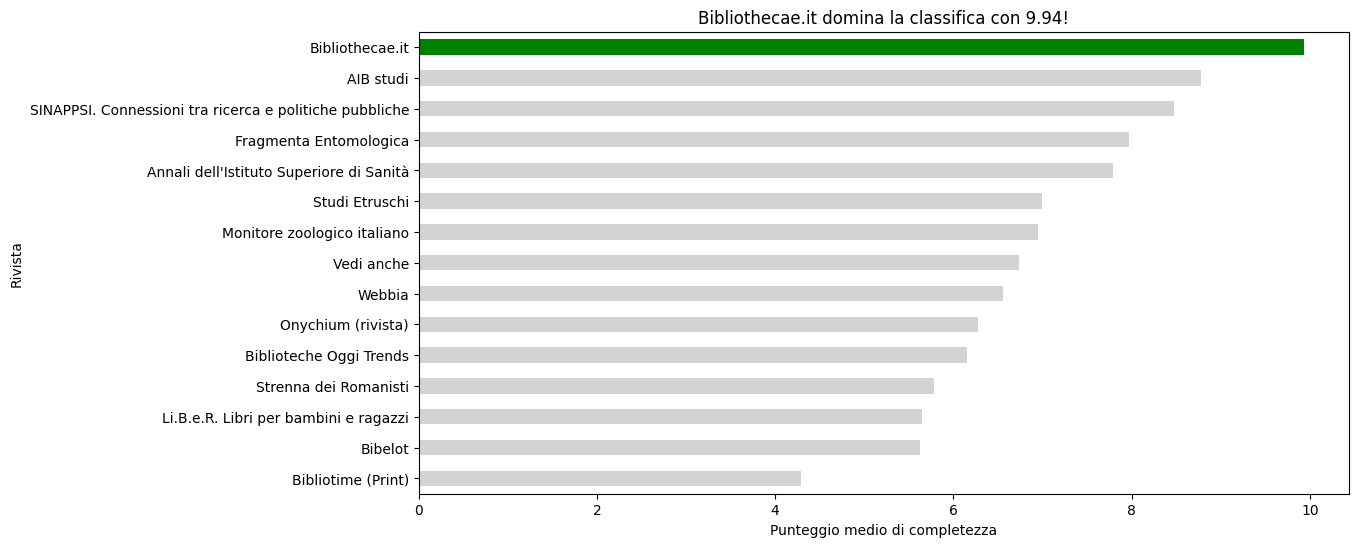

In [232]:
top15_riviste = completezza_metadati_riviste.head(15)

top15_riviste["completezza_media"].sort_values().plot.barh(
    figsize=(12, 6),
    title="Bibliothecae.it domina la classifica con 9.94!",
    xlabel="Punteggio medio di completezza",
    ylabel="Rivista",
    color = ['lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'lightgray', 'green'],
    legend=False
)

L'analisi mostra che Bibliothecae.it ottiene un punteggio medio pari a 9,94/10, risultando **la rivista con i metadati più completi dell'intero dataset**. L'unico elemento che determina una lieve riduzione del punteggio è la mancanza, in alcuni record, dell'indicazione degli argomenti.

Interessante è il confronto con AIB studi, che, pur essendo la rivista più rappresentata nel dataset (357 articoli contro i 337 di Bibliothecae.it), presenta un punteggio medio inferiore (8,77/10).

Questi risultati suggeriscono che l'elevata presenza di Bibliothecae.it non sia riconducibile esclusivamente alla sua produzione editoriale, ma possa essere favorita anche dall'elevata completezza dei metadati associati ai suoi articoli. Pur non dimostrando un rapporto causale tra qualità dei metadati e frequenza di inclusione nel dataset, l'analisi sostiene l'ipotesi che **una migliore strutturazione e disponibilità delle informazioni bibliografiche contribuisca ad aumentare la visibilità delle pubblicazioni nei sistemi di dati aperti.**

In [233]:
print("Bibliothecae.it ha un punteggio di completezza di circa il",round((
            completezza_metadati_riviste.loc["Bibliothecae.it", "completezza_media"]
            - completezza_metadati_riviste.loc["AIB studi", "completezza_media"])
        / completezza_metadati_riviste.loc["AIB studi", "completezza_media"]* 100),"% più alto rispetto a AIB studi.")

Bibliothecae.it ha un punteggio di completezza di circa il 13 % più alto rispetto a AIB studi.


# 7. Conclusione

**Le leggi bibliometriche** hanno confermato alcune dinamiche attese, come il fatto che pochi autori concentrino una parte rilevante della produzione scientifica e che alcune riviste assumano un ruolo centrale all'interno del dataset. L'analisi esplicativa ci ha permesso di andare oltre la semplice descrizione dei dati e provare a capire cosa si nascondesse dietro ai fenomeni osservati.

Il risultato più interessante è **il caso di Bibliothecae.it**. La sua presenza così significativa nel dataset, molto vicina a quella di una rivista storica come AIB studi, ha fatto nascere una nuova domanda: questa presenza era dovuta soltanto al numero di articoli pubblicati o poteva esserci anche un altro elemento in gioco?

Da qui è nata l'idea di osservare il dataset da una prospettiva diversa, non concentrandosi solo sugli articoli ma anche sulle informazioni che li descrivono. L'analisi della completezza dei metadati ha mostrato che **la qualità e la ricchezza delle informazioni bibliografiche possono rappresentare un elemento importante per la visibilità delle pubblicazioni all'interno dei sistemi digitali.**

I metadati, spesso considerati un dettaglio tecnico, si sono rivelati invece **una parte fondamentale della storia.**